# NIFTY 50 — Exploratory Data Analysis\n\nThis notebook explores the cleaned, feature-engineered dataset produced by the preprocessing pipeline.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Resolve project root robustly regardless of working directory
_this_dir = Path(__file__).resolve().parent if "__file__" in dir() else Path.cwd()
for _candidate in [_this_dir, _this_dir.parent, _this_dir.parents[1], _this_dir.parents[2]]:
    if (_candidate / "ml" / "pipeline" / "ingest.py").exists():
        PROJECT_ROOT = _candidate
        break
    if (_candidate / "Dataset" / "metadata.json").exists():
        PROJECT_ROOT = _candidate
        break
else:
    PROJECT_ROOT = _this_dir

sys.path.insert(0, str(PROJECT_ROOT))

# Load the raw ingested + cleaned data (pre-scaling) for meaningful EDA
from ml.pipeline.ingest import ingest
from ml.pipeline.clean import clean
from ml.pipeline.features import add_features

df = ingest()
df = clean(df)
df = add_features(df)

print(f"Shape: {df.shape}")
df.head()

C:\Users\raman\OneDrive\Desktop\ML_Project_Practice\Stock-market-analysis\ml\pipeline\clean.py:28: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return group["Volume"].clip(upper=cap)


Shape: (287263, 37)


,Date,Ticker,Company_Name,Sector,Open,High,Low,Close,Volume,Dividend,...,Lag_Return_1,Price_Range,Price_Range_Pct,Close_vs_MA50,Close_vs_MA200,RSI_14,MACD,MACD_Signal,Target_Close,Target_Direction
0,2002-09-04,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.025180,0.025261,0.024971,0.025052,478760.0,1.454228,...,NaN,0.000290,0.011517,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.025084,1
1,2002-09-05,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.025261,0.025261,0.025003,0.025084,492461.0,0.000000,...,-5.676113,0.000258,0.010204,NaN,NaN,NaN,2.571002e-06,5.142004e-07,0.025035,0
2,2002-09-06,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.025213,0.025213,0.024729,0.025035,510128.0,0.000000,...,0.001287,0.000483,0.019169,-4.258056,NaN,NaN,7.010779e-07,5.515759e-07,0.024745,0
3,2002-09-09,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.024166,0.024890,0.024166,0.024745,488272.0,0.000000,...,-0.001927,0.000725,0.030000,-4.835976,NaN,NaN,-2.390533e-05,-4.339804e-06,0.024745,0
4,2002-09-10,ADANIENT.NS,Adani Enterprises Ltd.,Infrastructure,0.024745,0.024745,0.024745,0.024745,0.0,0.000000,...,-0.011583,0.000000,0.000000,-5.744422,NaN,NaN,-4.291142e-05,-1.205413e-05,0.024649,0


## 1. Distribution of Close Price per Sector

C:\Users\raman\AppData\Local\Temp\ipykernel_29088\97818925.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


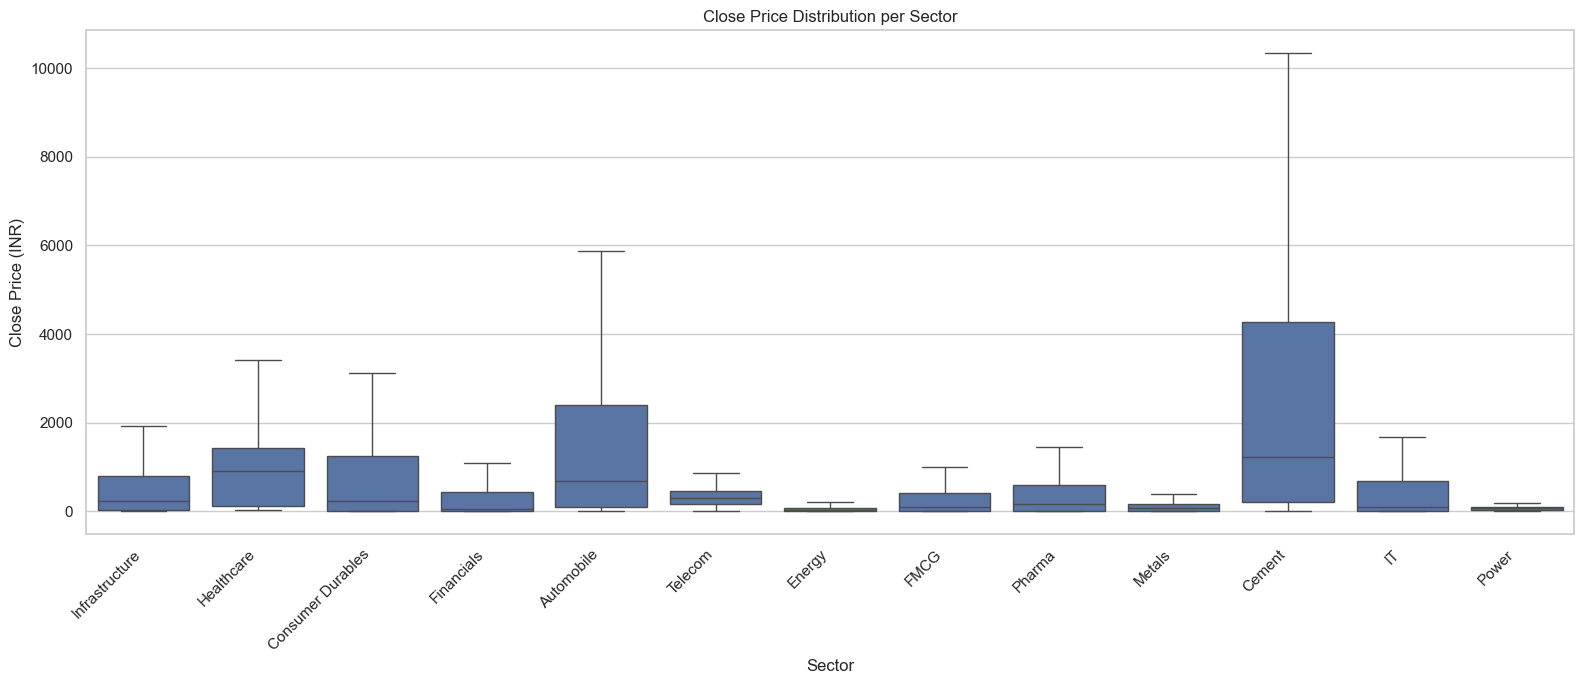

In [2]:
fig, ax = plt.subplots(figsize=(16, 7))
sectors = sorted(df["Sector"].unique())
sns.boxplot(data=df, x="Sector", y="Close", ax=ax, showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_title("Close Price Distribution per Sector")
ax.set_ylabel("Close Price (INR)")
plt.tight_layout()
plt.show()

## 2. Correlation Heatmap of Numeric Features

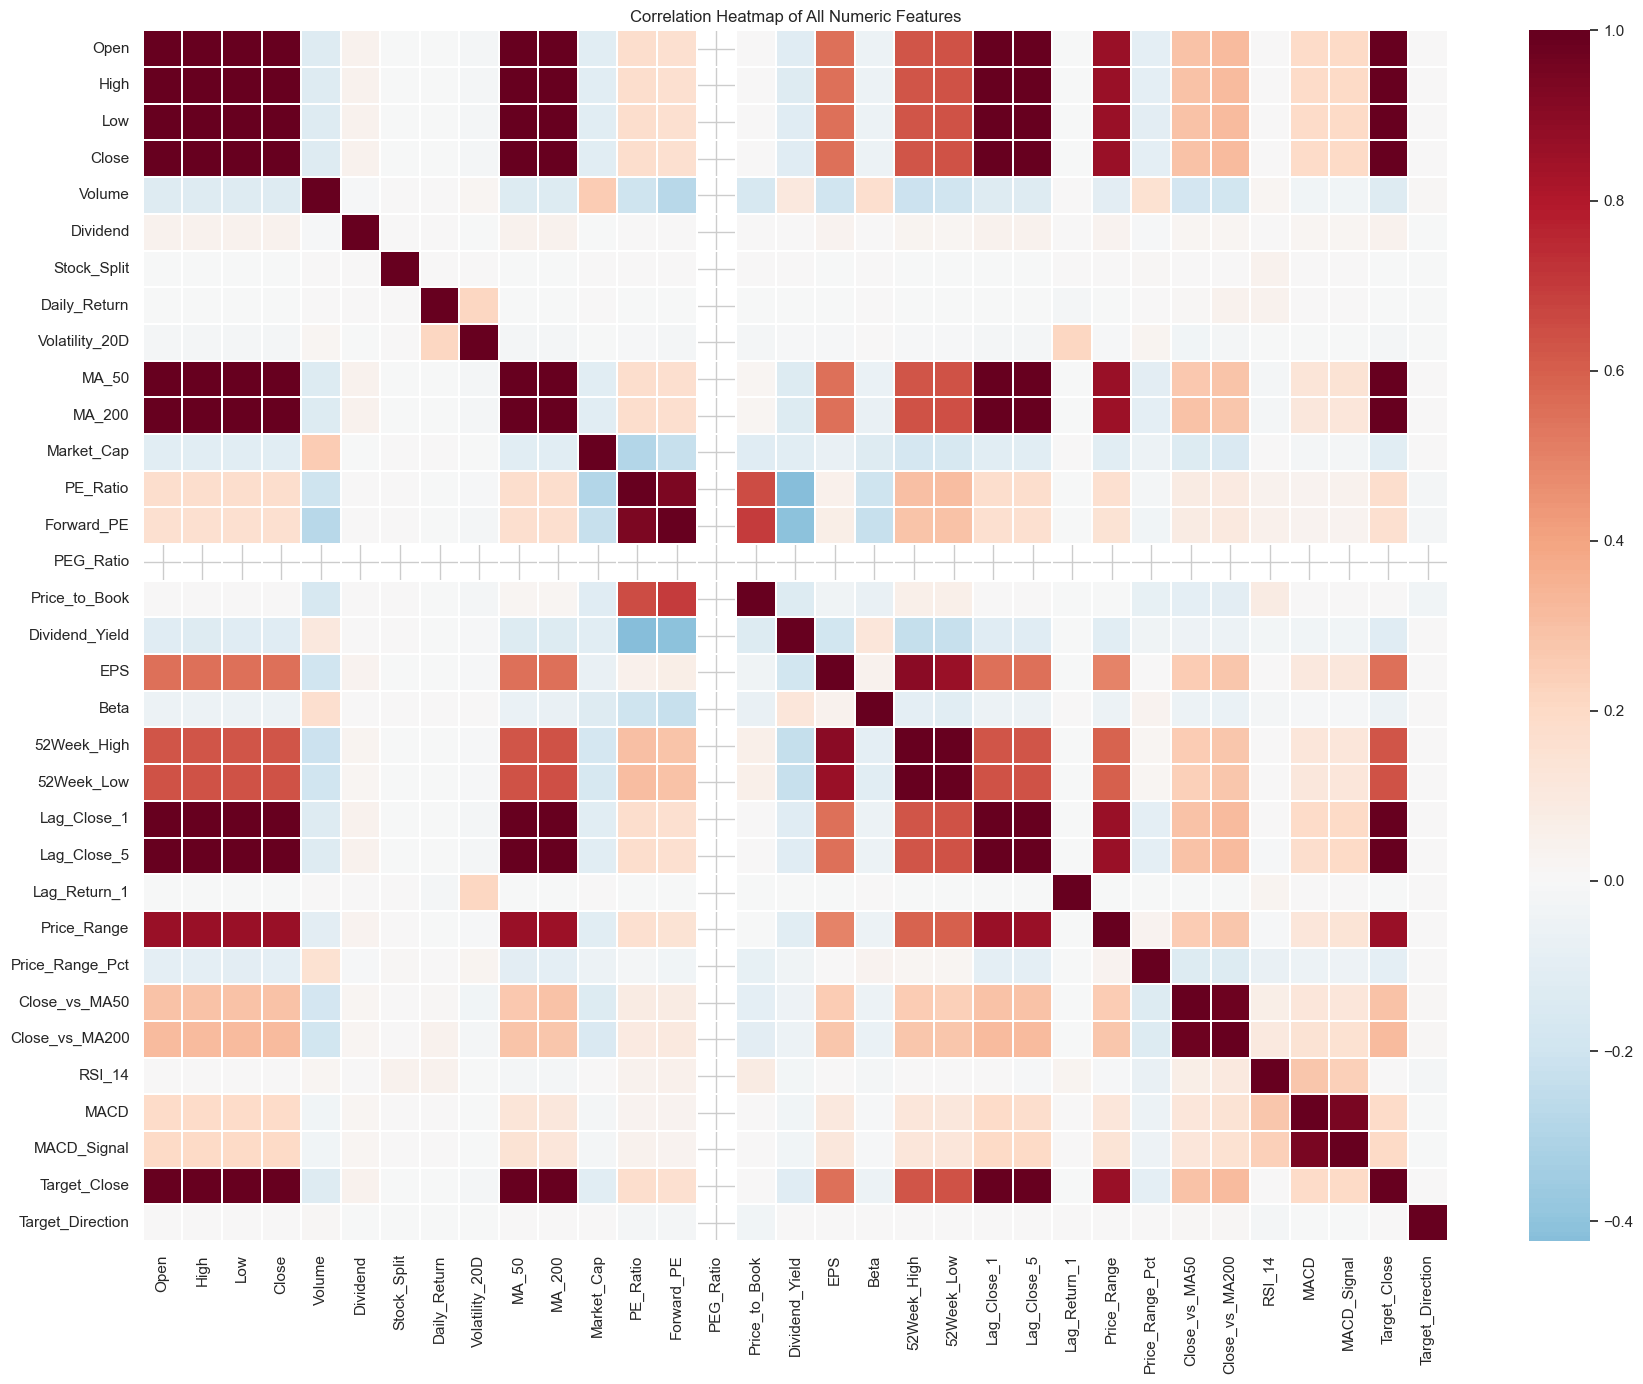

In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(corr, annot=False, cmap="RdBu_r", center=0, linewidths=0.3, ax=ax)
ax.set_title("Correlation Heatmap of All Numeric Features")
plt.tight_layout()
plt.show()

## 3. Missing Value Summary

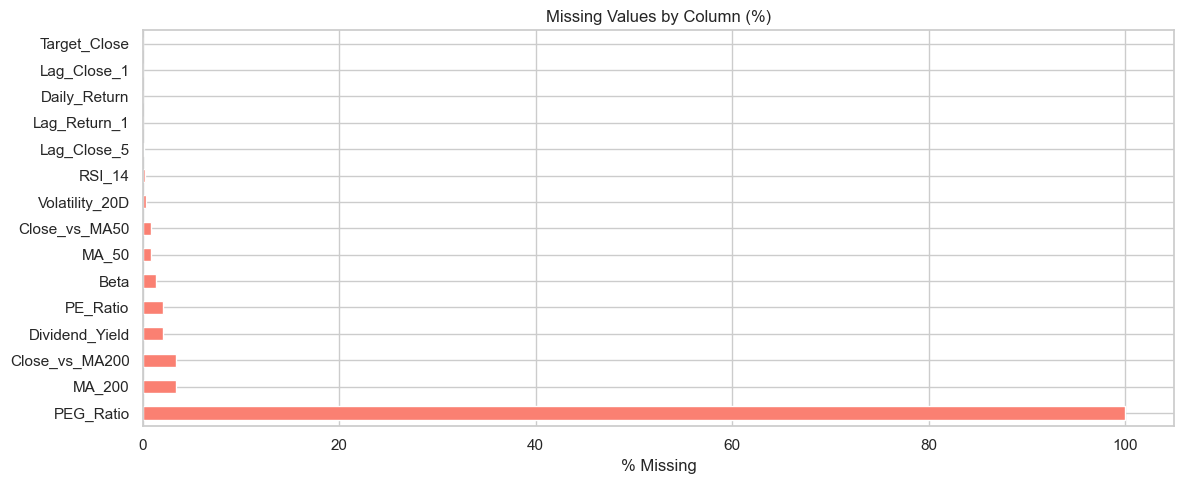

,Missing Count,Missing %
PEG_Ratio,287263,100.00
MA_200,9704,3.38
Close_vs_MA200,9704,3.38
Dividend_Yield,5857,2.04
PE_Ratio,5857,2.04
Beta,3759,1.31
MA_50,2354,0.82
Close_vs_MA50,2354,0.82
Volatility_20D,960,0.33
RSI_14,686,0.24


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0].sort_values("Missing %", ascending=False)

if missing_df.empty:
    print("No missing values in the dataset!")
else:
    fig, ax = plt.subplots(figsize=(12, 5))
    missing_df["Missing %"].plot(kind="barh", ax=ax, color="salmon")
    ax.set_title("Missing Values by Column (%)")
    ax.set_xlabel("% Missing")
    plt.tight_layout()
    plt.show()

missing_df

## 4. Rolling Volatility Chart — Top 5 Stocks by Market Cap

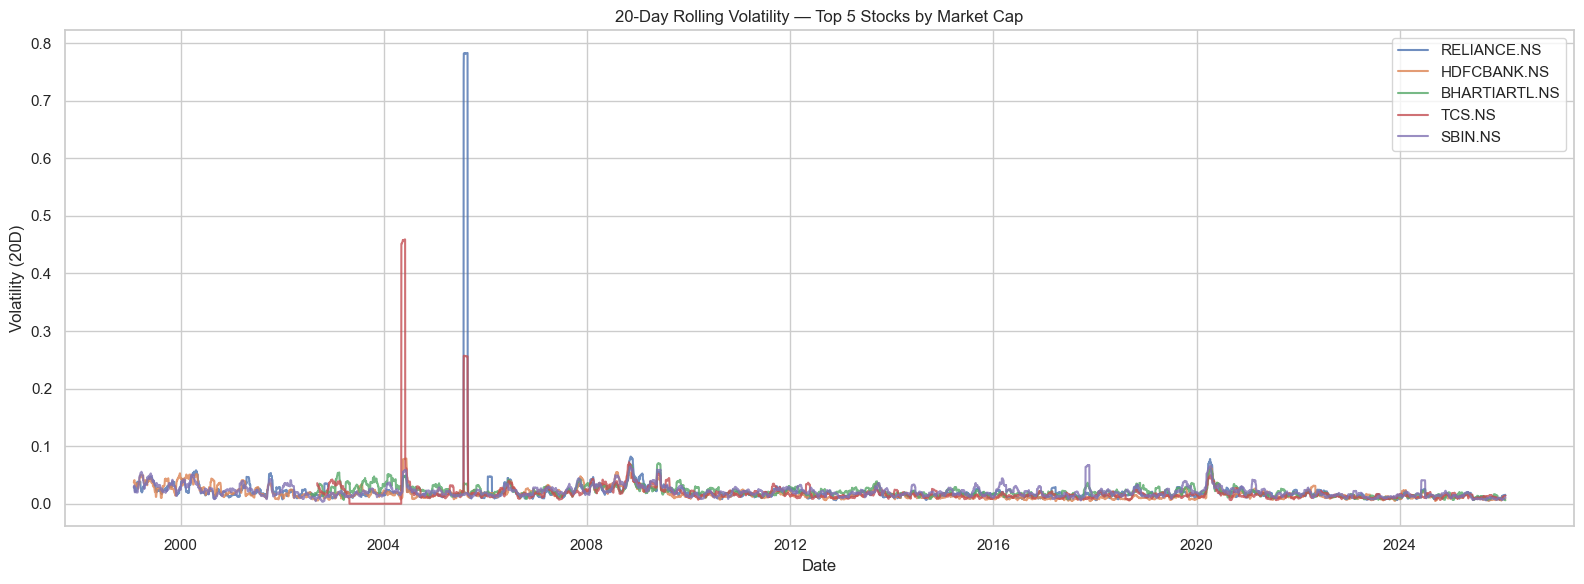

In [5]:
# Pick top 5 stocks by median market cap
top5 = (
    df.groupby("Ticker")["Market_Cap"]
    .median()
    .nlargest(5)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(16, 6))
for ticker in top5:
    sub = df[df["Ticker"] == ticker].set_index("Date")
    ax.plot(sub.index, sub["Volatility_20D"], label=ticker, alpha=0.8)

ax.set_title("20-Day Rolling Volatility — Top 5 Stocks by Market Cap")
ax.set_ylabel("Volatility (20D)")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sector-wise Average Daily Return Comparison

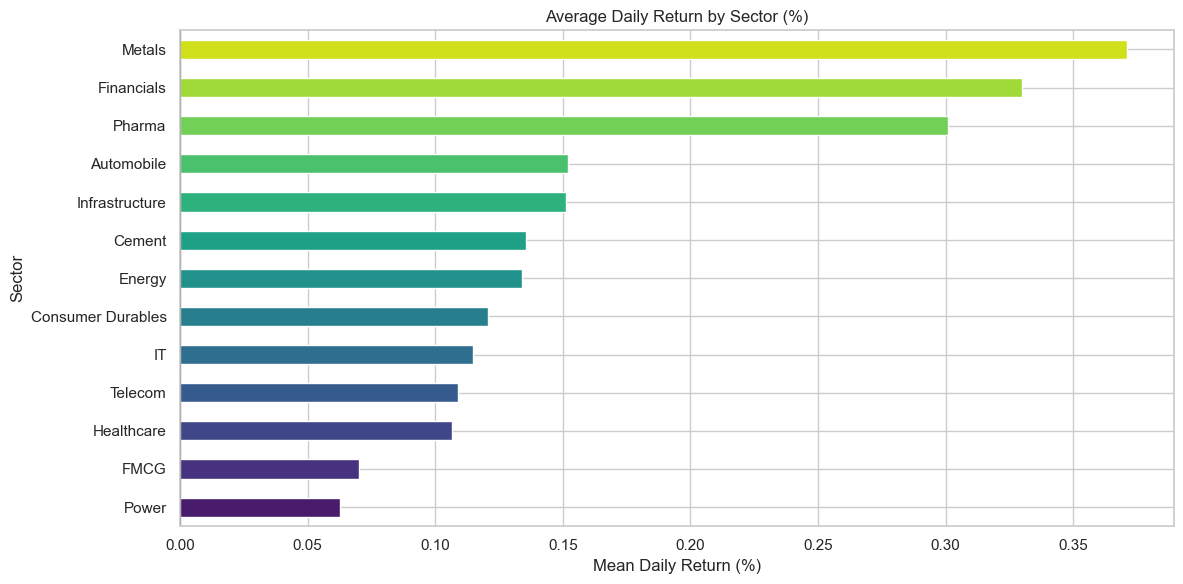

In [6]:
sector_returns = (
    df.groupby("Sector")["Daily_Return"]
    .mean()
    .sort_values(ascending=True)
    * 100  # convert to percentage
)

fig, ax = plt.subplots(figsize=(12, 6))
sector_returns.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(sector_returns)))
ax.set_title("Average Daily Return by Sector (%)")
ax.set_xlabel("Mean Daily Return (%)")
ax.set_ylabel("Sector")
ax.axvline(x=0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()